### Separate notebook just to run and compare final algorith more cleanly // no need to have the whole exploration process in the same place

In [2]:
import numpy as np 
from bandit import Bandits_final

In [3]:
def epsilon_greedy(MAB, episodes=1000, epsilon=0.1):
    num_arms = MAB.k

    estimated_rewards = np.zeros(num_arms)
    action_counts = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int)
    rewards = np.zeros(episodes)

    for ep in range(episodes):
        if np.random.rand() < epsilon:
            action = np.random.randint(num_arms)
        else:
            action = np.argmax(estimated_rewards)

        _, reward, _, _, _ = MAB.step(action)

        action_counts[action] += 1
        estimated_rewards[action] += (reward - estimated_rewards[action]) / action_counts[action]

        actions[ep] = action
        rewards[ep] = reward

    return actions, rewards, estimated_rewards, action_counts

In [4]:
def Customized_algo(MAB, episodes=1000, epsilon=0.1, alpha=5.0, window=20, short_window=3, k=4.0, reset_factor=0.5, reset_epsilon=0.3):
    num_arms = MAB.k

    estimated_rewards = np.zeros(num_arms)
    action_counts = np.zeros(num_arms)

    actions = np.zeros(episodes, dtype=int)
    rewards = np.zeros(episodes)
    trigger_steps = []

    current_epsilon = epsilon

    for ep in range(episodes):
        if np.random.rand() < current_epsilon:
            action = np.random.randint(num_arms)
        else:
            action = np.argmax(estimated_rewards)

        _, reward, _, _, _ = MAB.step(action)

        actions[ep] = action
        rewards[ep] = reward

        if ep >= window:
            long_recent = rewards[ep-window:ep]
            short_recent = rewards[ep-short_window:ep]
            ma = np.mean(long_recent)
            short_ma = np.mean(short_recent)
            std = np.std(long_recent)

            if std > 0 and abs(ma - short_ma) > k * std:
                estimated_rewards *= reset_factor
                current_epsilon = reset_epsilon
                trigger_steps.append(ep)

        action_counts[action] += 1
        estimated_rewards[action] += (reward - estimated_rewards[action]) / alpha

        if current_epsilon > epsilon:
            current_epsilon = max(epsilon, current_epsilon * 0.98)

    return actions, rewards, estimated_rewards, action_counts, np.array(trigger_steps)

In [10]:
def evaluate_Customized_algo(param_grid, episodes=1000, runs=20):
    results = []

    for epsilon in param_grid['epsilon']:
        for alpha in param_grid['alpha']:
            for window in param_grid['window']:
                for short_window in param_grid['short_window']:
                    for k in param_grid['k']:
                        for reset_factor in param_grid['reset_factor']:
                            for reset_epsilon in param_grid['reset_epsilon']:
                                total_rewards = []
                                trigger_counts = []

                                for _ in range(runs):
                                    MAB = Bandits_final()
                                    _, rewards, _, _, triggers = Customized_algo(
                                        MAB,
                                        episodes=episodes,
                                        epsilon=epsilon,
                                        alpha=alpha,
                                        window=window,
                                        short_window=short_window,
                                        k=k,
                                        reset_factor=reset_factor,
                                        reset_epsilon=reset_epsilon,
                                    )
                                    total_rewards.append(np.sum(rewards))
                                    trigger_counts.append(len(triggers))

                                results.append({
                                    'epsilon': epsilon,
                                    'alpha': alpha,
                                    'window': window,
                                    'short_window': short_window,
                                    'k': k,
                                    'reset_factor': reset_factor,
                                    'reset_epsilon': reset_epsilon,
                                    'mean_total_reward': np.mean(total_rewards),
                                    'std_total_reward': np.std(total_rewards),
                                    'mean_trigger_count': np.mean(trigger_counts),
                                    'std_trigger_count': np.std(trigger_counts),
                                })

    return sorted(results, key=lambda row: row['mean_total_reward'], reverse=True)

custom_param_grid = {
    'epsilon': [0.1, 0.15, 0.2],
    'alpha': [3.0, 5.0],
    'window': [10, 20],
    'short_window': [3, 5],
    'k': [1.25, 1.5, 2.0],
    'reset_factor': [0.2],
    'reset_epsilon': [0.5],
}

custom_sweep = evaluate_Customized_algo(custom_param_grid, episodes=1000, runs=20)
custom_sweep[:10]


[{'epsilon': 0.15,
  'alpha': 5.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3918.8929960495952),
  'std_total_reward': np.float64(459.65975003499057),
  'mean_trigger_count': np.float64(2.35),
  'std_trigger_count': np.float64(2.95423424934449)},
 {'epsilon': 0.15,
  'alpha': 3.0,
  'window': 20,
  'short_window': 3,
  'k': 2.0,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3906.579731295967),
  'std_total_reward': np.float64(489.32574409076847),
  'mean_trigger_count': np.float64(0.05),
  'std_trigger_count': np.float64(0.21794494717703364)},
 {'epsilon': 0.1,
  'alpha': 5.0,
  'window': 20,
  'short_window': 5,
  'k': 1.5,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3884.7621361152073),
  'std_total_reward': np.float64(770.627565822692),
  'mean_trigger_count': np.float64(0.05),
  'std_trigger_count': np.float64(0.2179449471

In [11]:
# looking at the range where i suspect the trigger mechanism is working. 
trigger_filtered = [
    row for row in custom_sweep
    if 1 <= row['mean_trigger_count'] <= 10
]

trigger_filtered[:10]

[{'epsilon': 0.15,
  'alpha': 5.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3918.8929960495952),
  'std_total_reward': np.float64(459.65975003499057),
  'mean_trigger_count': np.float64(2.35),
  'std_trigger_count': np.float64(2.95423424934449)},
 {'epsilon': 0.1,
  'alpha': 5.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3881.9701902971924),
  'std_total_reward': np.float64(626.5449225812207),
  'mean_trigger_count': np.float64(1.55),
  'std_trigger_count': np.float64(1.6575584454250778)},
 {'epsilon': 0.1,
  'alpha': 3.0,
  'window': 20,
  'short_window': 5,
  'k': 1.25,
  'reset_factor': 0.2,
  'reset_epsilon': 0.5,
  'mean_total_reward': np.float64(3758.3210842148123),
  'std_total_reward': np.float64(671.437665257443),
  'mean_trigger_count': np.float64(2.25),
  'std_trigger_count': np.float64(2.0217566619

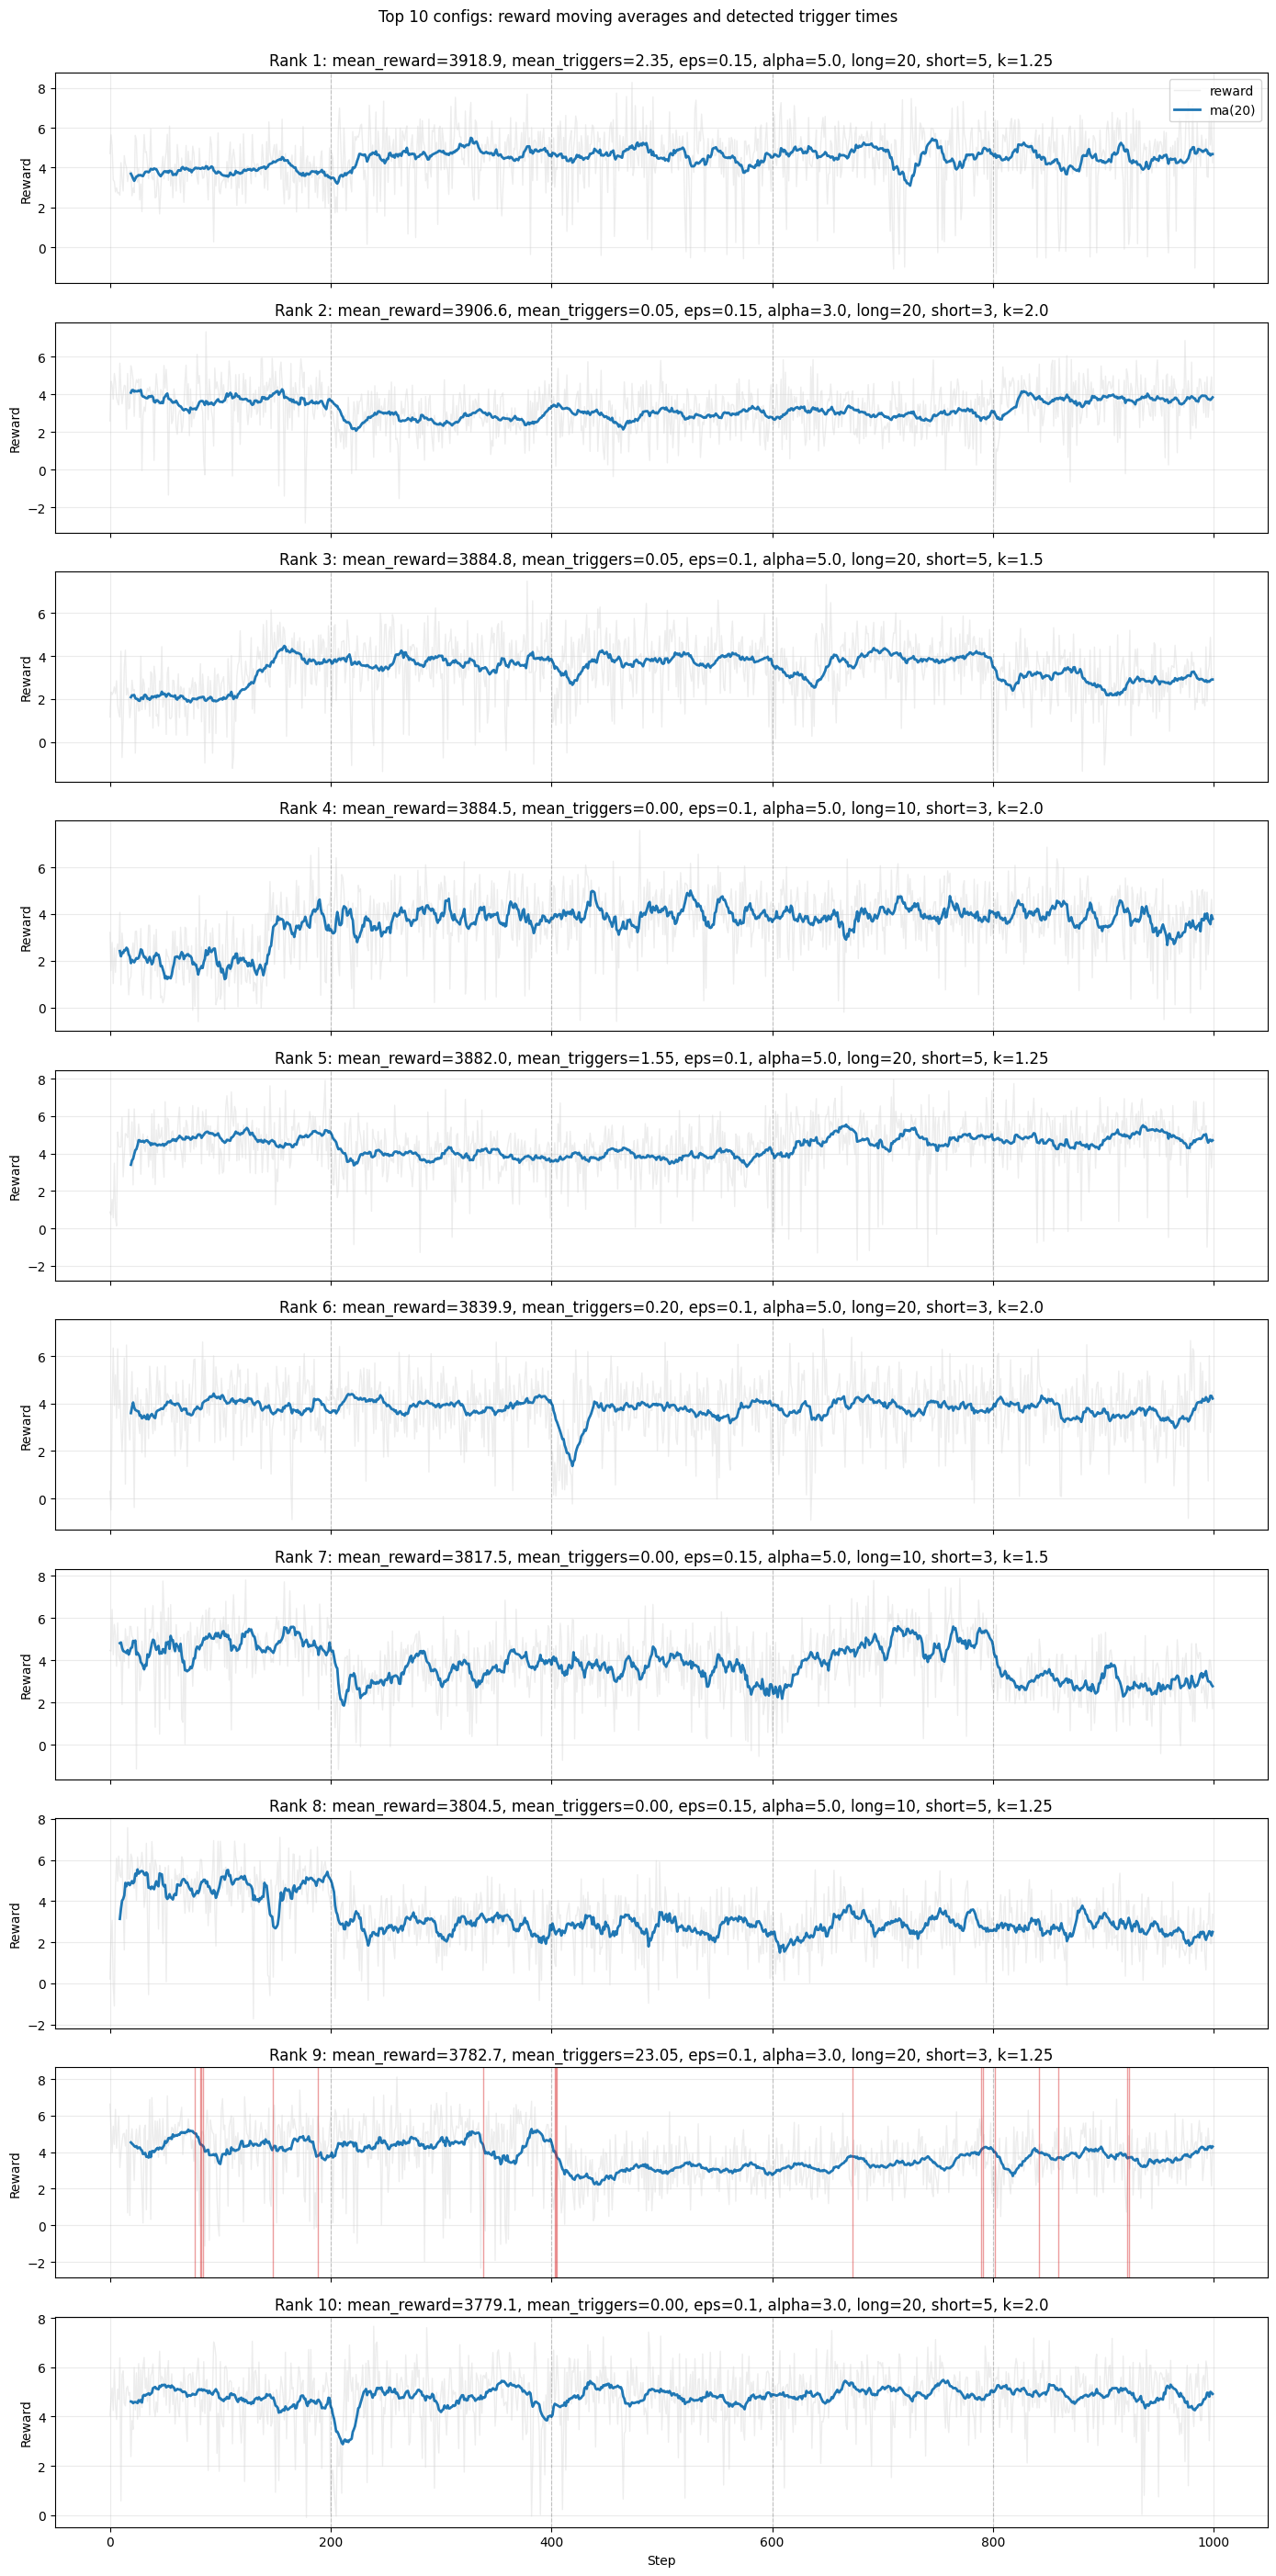

[{'rank': 1,
  'mean_total_reward': 3918.8929960495952,
  'mean_trigger_count': 2.35,
  'trigger_count_this_run': 0},
 {'rank': 2,
  'mean_total_reward': 3906.579731295967,
  'mean_trigger_count': 0.05,
  'trigger_count_this_run': 0},
 {'rank': 3,
  'mean_total_reward': 3884.7621361152073,
  'mean_trigger_count': 0.05,
  'trigger_count_this_run': 0},
 {'rank': 4,
  'mean_total_reward': 3884.5427534879514,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 5,
  'mean_total_reward': 3881.9701902971924,
  'mean_trigger_count': 1.55,
  'trigger_count_this_run': 0},
 {'rank': 6,
  'mean_total_reward': 3839.856869758495,
  'mean_trigger_count': 0.2,
  'trigger_count_this_run': 0},
 {'rank': 7,
  'mean_total_reward': 3817.470307908649,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 8,
  'mean_total_reward': 3804.484552622438,
  'mean_trigger_count': 0.0,
  'trigger_count_this_run': 0},
 {'rank': 9,
  'mean_total_reward': 3782.654537683081,
  'mean_t

In [12]:
import matplotlib.pyplot as plt

def moving_average(rewards, window):
    rewards = np.asarray(rewards)
    window = int(window)
    if window <= 1 or len(rewards) < window:
        return np.arange(len(rewards)), rewards
    ma = np.convolve(rewards, np.ones(window) / window, mode='valid')
    x_ma = np.arange(window - 1, len(rewards))
    return x_ma, ma

top10_configs = custom_sweep[:10]
episodes = 1000
change_checkpoints = np.arange(200, episodes, 200)

fig, axes = plt.subplots(len(top10_configs), 1, figsize=(14, 2.8 * len(top10_configs)), sharex=True)
if len(top10_configs) == 1:
    axes = [axes]

top10_run_summary = []

for rank, (ax, config) in enumerate(zip(axes, top10_configs), start=1):
    _, rewards, _, _, triggers = Customized_algo(
        Bandits_final(),
        episodes=episodes,
        epsilon=config['epsilon'],
        alpha=config['alpha'],
        window=int(config['window']),
        short_window=int(config['short_window']),
        k=config['k'],
        reset_factor=config['reset_factor'],
        reset_epsilon=config['reset_epsilon'],
    )

    ma_window = int(config['window'])
    x_ma, reward_ma = moving_average(rewards, ma_window)

    ax.plot(rewards, color='lightgray', alpha=0.4, linewidth=1, label='reward')
    ax.plot(x_ma, reward_ma, color='tab:blue', linewidth=2, label=f'ma({ma_window})')

    for step in change_checkpoints:
        ax.axvline(step, color='black', linestyle='--', alpha=0.18, linewidth=0.8)
    for step in triggers:
        ax.axvline(step, color='tab:red', alpha=0.45, linewidth=1)

    ax.set_ylabel('Reward')
    ax.grid(True, alpha=0.25)
    ax.set_title(
        f"Rank {rank}: mean_reward={config['mean_total_reward']:.1f}, mean_triggers={config['mean_trigger_count']:.2f}, "
        f"eps={config['epsilon']}, alpha={config['alpha']}, long={int(config['window'])}, short={int(config['short_window'])}, k={config['k']}"
    )

    top10_run_summary.append({
        'rank': rank,
        'mean_total_reward': float(config['mean_total_reward']),
        'mean_trigger_count': float(config['mean_trigger_count']),
        'trigger_count_this_run': int(len(triggers)),
    })

axes[0].legend(loc='upper right')
axes[-1].set_xlabel('Step')
fig.suptitle('Top 10 configs: reward moving averages and detected trigger times', y=1.0)
plt.tight_layout()
plt.show()

top10_run_summary
